# Ejemplos del conjunto de datos

Genera una rejilla de fotogramas de ejemplo para la memoria: una fila por categoría
(limpio y los tres niveles de corrupción) y varias columnas con ejemplos aleatorios.

Ajusta `SPLIT`, `N_COLS` y `SEED` a gusto. La figura se guarda como `ejemplos_dataset.png`
en esta misma carpeta; después cópiala a la carpeta `figuras/` del proyecto LaTeX.

Figura guardada en ejemplos_dataset.png


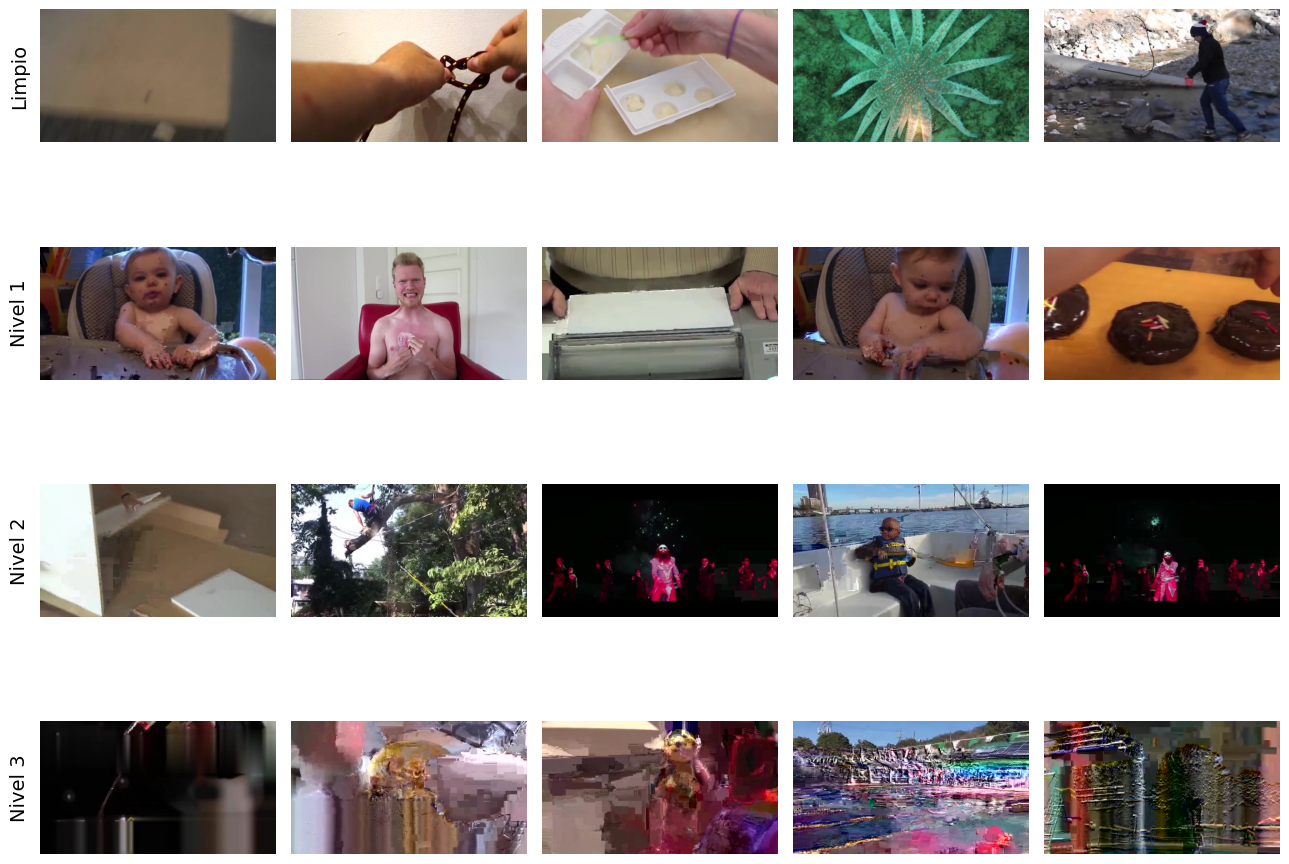

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import random

# --- Configuración ---
SPLIT  = "test"                # "train" o "test"
N_COLS = 5                     # nº de ejemplos por categoría
SEED   = 8                    # semilla para reproducibilidad
OUTPUT = "ejemplos_dataset.png"

FRAMES_DIR = Path("../frames") / SPLIT

# Categorías (fila -> carpeta)
categorias = {
    "Limpio":  FRAMES_DIR / "clean",
    "Nivel 1": FRAMES_DIR / "corrupted" / "level1",
    "Nivel 2": FRAMES_DIR / "corrupted" / "level2",
    "Nivel 3": FRAMES_DIR / "corrupted" / "level3",
}

random.seed(SEED)

def muestrear(carpeta, n):
    """Devuelve n rutas de fotogramas elegidos al azar de la carpeta."""
    archivos = list(carpeta.glob("*.jpg"))
    return random.sample(archivos, min(n, len(archivos)))

n_rows = len(categorias)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(2.6 * N_COLS, 2.6 * n_rows))

for r, (etiqueta, carpeta) in enumerate(categorias.items()):
    muestras = muestrear(carpeta, N_COLS)
    for c in range(N_COLS):
        ax = axes[r, c]
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)
        if c < len(muestras):
            ax.imshow(mpimg.imread(str(muestras[c])))
        else:
            ax.set_facecolor("white")
    # Etiqueta de la fila a la izquierda
    axes[r, 0].set_ylabel(etiqueta, fontsize=14, rotation=90, labelpad=8)

plt.tight_layout()
plt.savefig(OUTPUT, dpi=150, bbox_inches="tight")
print(f"Figura guardada en {OUTPUT}")
plt.show()